In [1]:


import os

REPO_DIR = "/kaggle/working/palmistry"

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/yeonsumia/palmistry.git {REPO_DIR}
else:
    print("Repo already present, skipping clone.")

%cd {REPO_DIR}/code



Cloning into '/kaggle/working/palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 31.71 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.
/kaggle/working/palmistry/code


In [2]:
# --- Install dependencies ---
!pip install -r requirements.txt -q
!pip install groq fpdf2 -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 69.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 48.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 11.0 MB/s eta 0:00:00


In [3]:
# --- Imports ---
import os
import torch
from model import UNet
from detection import detect

# --- Load the UNet checkpoint ---
device = torch.device("cpu")
net = UNet(3, 1)
checkpoint = torch.load("checkpoint/checkpoint_aug_epoch70.pth", map_location=device)
net.load_state_dict(checkpoint)
net.to(device)
net.eval()
print("UNet model loaded")

UNet model loaded


In [4]:
# --- Groq client setup (works on Kaggle now, and in VS Code later) ---
from groq import Groq

def get_groq_api_key():
    # Try Kaggle secrets first
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("GROQ_API_KEY")
    except Exception:
        pass
    # Fall back to environment variable (this is what VS Code will use)
    key = os.environ.get("GROQ_API_KEY")
    if key is None:
        raise ValueError(
            "GROQ_API_KEY not found. On Kaggle, add it under Add-ons > Secrets. "
            "In VS Code, set it as an environment variable."
        )
    return key

groq_client = Groq(api_key=get_groq_api_key())
print("Groq client configured")

Groq client configured


In [5]:
dataset_path = "/kaggle/input/datasets/monashree104326/hand-test"  
print(os.listdir(dataset_path))

['my_palm_2.jpeg', 'my_palm_4.jpeg', 'my_palm_1.jpeg', 'my_palm_5.jpeg', 'my_palm_3.jpeg']


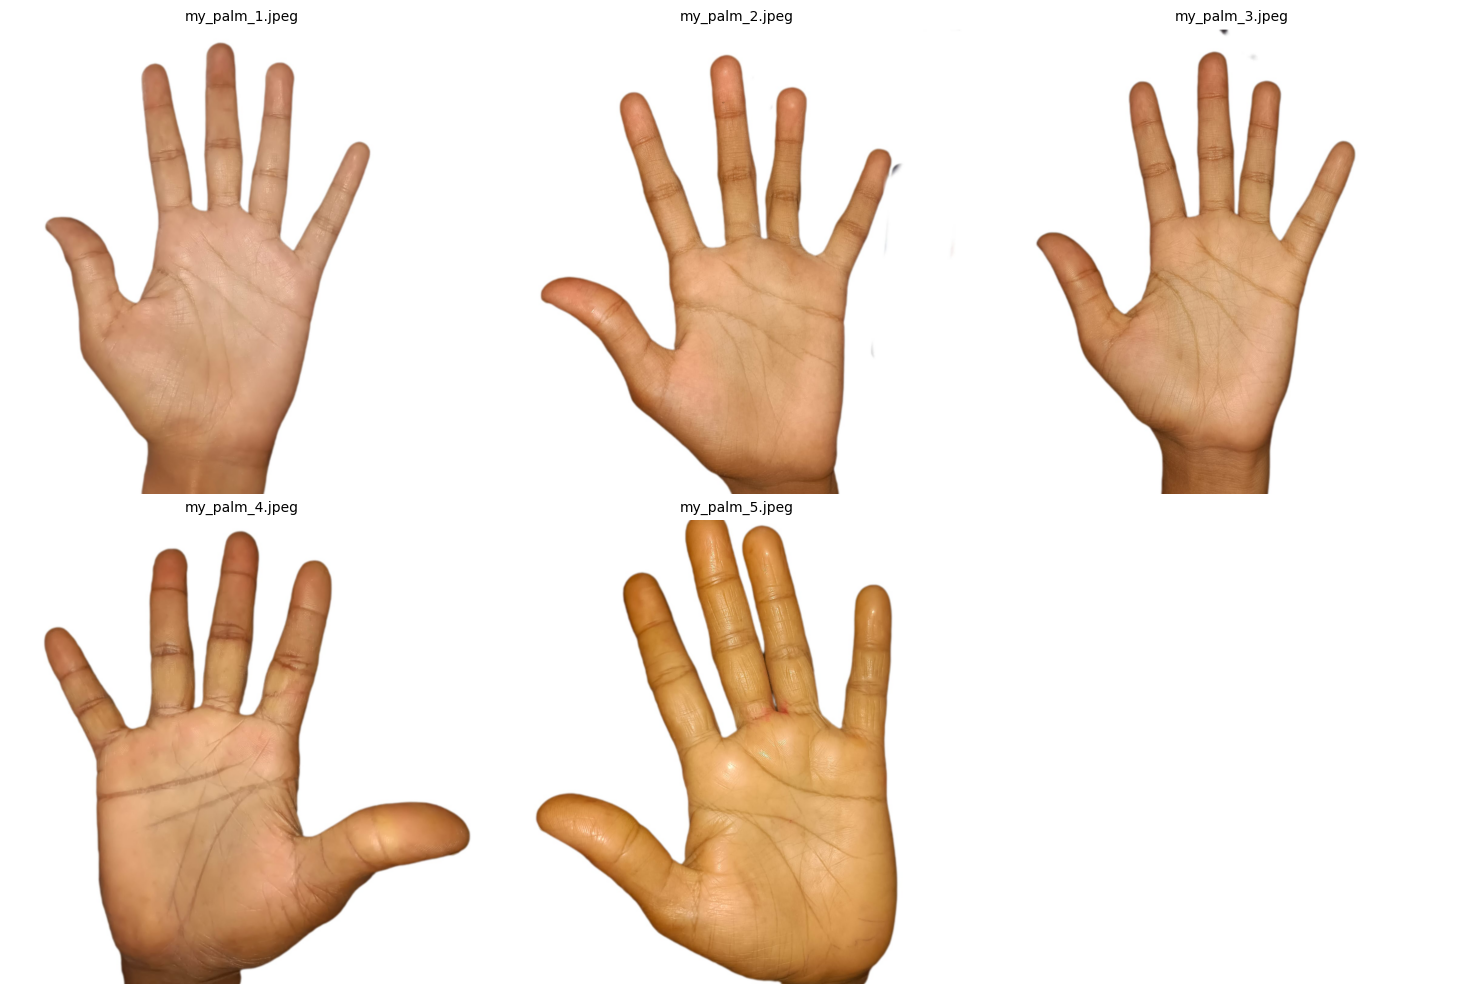

In [6]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image



# Get all image files
image_files = sorted([
    f for f in os.listdir(dataset_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

# Grid size
cols = 3
rows = math.ceil(len(image_files) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for ax, img_name in zip(axes, image_files):
    img = Image.open(os.path.join(dataset_path, img_name))
    ax.imshow(img)
    ax.set_title(img_name, fontsize=10)
    ax.axis("off")

# Hide unused subplots
for ax in axes[len(image_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
%%writefile rectification.py
import numpy as np
import cv2
import mediapipe as mp
import urllib.request

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

WARP_SUCCESS = 1


# Download MediaPipe Hand Landmarker model

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = "hand_landmarker.task"

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

def detect_landmarks(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image = cv2.flip(image, 1)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)
    if len(detection_result.hand_landmarks) == 0:
        return None
    return detection_result.hand_landmarks[0]

def warp_image(path_to_image, path_to_warped_image):
    pts_target_normalized = np.float32([
        [1-0.48203104734420776, 0.9063420295715332],
        [1-0.6043621301651001, 0.8119394183158875],
        [1-0.6763232946395874, 0.6790258884429932],
        [1-0.7340714335441589, 0.5716733932495117],
        [1-0.7896472215652466, 0.5098430514335632],
        [1-0.5655680298805237, 0.5117031931877136],
        [1-0.5979393720626831, 0.36575648188591003],
        [1-0.6135331392288208, 0.2713503837585449],
        [1-0.6196483373641968, 0.19251111149787903],
        [1-0.4928809702396393, 0.4982593059539795],
        [1-0.4899863600730896, 0.3213786780834198],
        [1-0.4894656836986542, 0.21283167600631714],
        [1-0.48334982991218567, 0.12900274991989136],
        [1-0.4258815348148346, 0.5180916786193848],
        [1-0.4033462107181549, 0.3581996262073517],
        [1-0.3938145041465759, 0.2616880536079407],
        [1-0.38608720898628235, 0.1775170862674713],
        [1-0.36368662118911743, 0.5642163157463074],
        [1-0.33553171157836914, 0.44737303256988525],
        [1-0.3209102153778076, 0.3749568462371826],
        [1-0.31213682889938354, 0.3026996850967407]
    ])

    image = cv2.imread(path_to_image)
    if image is None:
        return None

    image = cv2.flip(image, 1)
    image_height, image_width = image.shape[:2]
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    detection_result = detector.detect(mp_image)
    if len(detection_result.hand_landmarks) == 0:
        return None

    hand_landmarks = detection_result.hand_landmarks[0]
    pts = np.float32([[lm.x * image_width, lm.y * image_height] for lm in hand_landmarks])
    pts_target = np.float32([[x * image_width, y * image_height] for x, y in pts_target_normalized])

    M, mask = cv2.findHomography(pts, pts_target, cv2.RANSAC, 5.0)
    if M is None:
        return None

    warped_image = cv2.warpPerspective(image, M, (image_width, image_height), borderMode=cv2.BORDER_REPLICATE)
    cv2.imwrite(path_to_warped_image, warped_image)
    return WARP_SUCCESS


def warp(path_to_input_image, path_to_warped_image):
    if path_to_input_image[-4:] in ["heic", "HEIC"]:
        path_to_input_image = path_to_input_image[:-4] + "jpg"
    warp_result = warp_image(path_to_input_image, path_to_warped_image)
    if warp_result is None:
        return None
    return WARP_SUCCESS

Overwriting rectification.py


In [8]:
%%writefile classification.py

import os
import glob
import numpy as np
import cv2
from PIL import Image
from skimage.morphology import skeletonize
import mediapipe as mp

def rectify(idx):
    img_path = './PLSU/PLSU/'
    image = cv2.imread(img_path + 'img/image' + str(idx) +'.jpg')
    image_mask = cv2.imread(img_path + 'Mask/image' + str(idx) + '.png', cv2.IMREAD_GRAYSCALE)
    mp_hands = mp.solutions.hands

    pts_index = list(range(21))
    pts_target_normalized = np.float32([[1-0.48203104734420776, 0.9063420295715332],
                                        [1-0.6043621301651001, 0.8119394183158875],
                                        [1-0.6763232946395874, 0.6790258884429932],
                                        [1-0.7340714335441589, 0.5716733932495117],
                                        [1-0.7896472215652466, 0.5098430514335632],
                                        [1-0.5655680298805237, 0.5117031931877136],
                                        [1-0.5979393720626831, 0.36575648188591003],
                                        [1-0.6135331392288208, 0.2713503837585449],
                                        [1-0.6196483373641968, 0.19251111149787903],
                                        [1-0.4928809702396393, 0.4982593059539795],
                                        [1-0.4899863600730896, 0.3213786780834198],
                                        [1-0.4894656836986542, 0.21283167600631714],
                                        [1-0.48334982991218567, 0.12900274991989136],
                                        [1-0.4258815348148346, 0.5180916786193848],
                                        [1-0.4033462107181549, 0.3581996262073517],
                                        [1-0.3938145041465759, 0.2616880536079407],
                                        [1-0.38608720898628235, 0.1775170862674713],
                                        [1-0.36368662118911743, 0.5642163157463074],
                                        [1-0.33553171157836914, 0.44737303256988525],
                                        [1-0.3209102153778076, 0.3749568462371826],
                                        [1-0.31213682889938354, 0.3026996850967407]])

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        if results.multi_hand_landmarks == None: return np.zeros_like(image)
        image_height, image_width, _ = image.shape
        hand_landmarks = results.multi_hand_landmarks[0]
        pts = np.float32([[hand_landmarks.landmark[i].x*image_width,
                           hand_landmarks.landmark[i].y*image_height] for i in pts_index])
        pts_target = np.float32([[x*image_width, y*image_height] for x,y in pts_target_normalized])
        M, mask = cv2.findHomography(pts, pts_target, cv2.RANSAC,5.0)
        rectified_image = cv2.warpPerspective(image_mask, M, (image_width, image_height))
        pil_img = Image.fromarray(rectified_image)
        rectified_image = np.asarray(pil_img.resize((1024, 1024), resample=Image.NEAREST))
        return rectified_image

def load_data(num_data):
    data_path = './line_sample'
    result_path = './line_sample_result'
    path_list = [data_path, result_path]
    for path in path_list:
        os.makedirs(path, exist_ok=True)

    cur_num_data = len(os.listdir(data_path))

    offset = 50
    img_path_list = [img_path for img_path in glob.glob('./PLSU/PLSU/Img/*')][offset+cur_num_data:offset+num_data]
    for i,img_path in enumerate(img_path_list):
        idx = img_path.split('image')[1].split('.')[0]
        rectified_image = rectify(idx)
        if np.sum(rectified_image)==0: continue
        cv2.imwrite('line_sample/image' + str(i+cur_num_data) + '.png', rectified_image)

def backtrack(lines_node, temp, graph, visited_node, finished_node, node):
    end_pt = True
    for next_node in graph[node].keys():
        if not visited_node[next_node]:
            end_pt = False
            temp.append(next_node)
            visited_node[next_node] = True
            finished_node[next_node] = True
            backtrack(lines_node, temp, graph, visited_node, finished_node, next_node)
            del temp[-1]
            visited_node[next_node] = False
    if end_pt:
        line_node = []
        line_node.extend(temp)
        lines_node.append(line_node)

def group(img):
    count = np.zeros(img.shape)
    nodes = []

    for j in range(1, img.shape[0] - 1):
        for i in range(1, img.shape[1] - 1):
            if img[j, i] == 0: continue
            count[j, i] = np.count_nonzero(img[j-1:j+2, i-1:i+2]) - 1
            if count[j, i] == 1 or count[j, i] >= 3:
                nodes.append((j, i))

    nodes.sort(key = lambda x : x[0]+x[1])

    graph = dict()
    for node in nodes:
        graph[node] = dict()

    not_visited = np.ones(img.shape)
    for node in nodes:
        y,x = node
        not_visited[y, x] = 0
        around = np.multiply(count[y-1:y+2, x-1:x+2], not_visited[y-1:y+2, x-1:x+2])
        next_pos = np.transpose(np.nonzero(around))
        if next_pos.shape[0] == 0: continue
        for dy,dx in next_pos:
            y,x = node
            next_y = y + dy - 1
            next_x = x + dx - 1
            if dx == 0 or (dy == 0 and dx == 1):
                dy,dx = 2-dy,2-dx
            temp_line = [[y,x,0,0], [next_y,next_x,dy-1,dx-1]]
            if count[next_y, next_x] == 1 or count[next_y, next_x] >= 3:
                not_visited[next_y, next_x] = 1
                graph[tuple(temp_line[0][:2])][tuple(temp_line[-1][:2])] = temp_line
                temp_line_rev = list(reversed(temp_line))
                graph[tuple(temp_line[-1][:2])][tuple(temp_line[0][:2])] = temp_line_rev
                continue

            while(True):
                y,x = temp_line[-1][:2]
                not_visited[y, x] = 0
                around = np.multiply(count[y-1:y+2, x-1:x+2], not_visited[y-1:y+2, x-1:x+2])
                next_pos = np.transpose(np.nonzero(around))
                if next_pos.shape[0] == 0: break

                next_y = y + next_pos[0][0] - 1
                next_x = x + next_pos[0][1] - 1
                dy,dx = next_y-y,next_x-x
                if dx == -1 or (dy == -1 and dx == 0):
                    dy,dx = -dy,-dx
                temp_line.append([next_y, next_x, dy, dx])
                not_visited[next_y, next_x] = 0

                if count[next_y, next_x] == 1 or count[next_y, next_x] >= 3:
                    graph[tuple(temp_line[0][:2])][tuple(temp_line[-1][:2])] = temp_line
                    temp_line_rev = list(reversed(temp_line))
                    graph[tuple(temp_line[-1][:2])][tuple(temp_line[0][:2])] = temp_line_rev
                    not_visited[next_y, next_x] = 1
                    break
        not_visited[node[0], node[1]] = 1

    lines_node = []
    visited_node = dict()
    finished_node = dict()
    for node in nodes:
        visited_node[node] = False
        finished_node[node] = False

    for node in nodes:
        if not finished_node[node]:
            temp = [node]
            visited_node[node] = True
            finished_node[node] = True
            backtrack(lines_node, temp, graph, visited_node, finished_node, node)

    lines = []
    for line_node in lines_node:
        num_node = len(line_node)
        if num_node == 1 : continue
        wrong = False
        line = []
        prev,cur = None,line_node[0]
        for i in range(1,num_node):
            nxt = line_node[i]
            if i>1 and (cur[0]-prev[0])*(nxt[0]-cur[0])+(cur[1]-prev[1])*(nxt[1]-cur[1])<0:
                wrong = True
                break
            line.extend(graph[cur][nxt])
            prev,cur = cur,nxt
        if wrong or len(line) < 10: continue
        lines.append(line)

    return lines

def classify_lines(centers, lines, image_height, image_width):
    classified_lines = [None, None, None]
    line_idx = [None, None, None]
    nearest = [1e9, 1e9, 1e9]

    feature_list = np.empty((0,24))
    for line in lines:
        feature = extract_feature(line, image_height, image_width)
        feature_list = np.vstack((feature_list,feature))

    num_lines = len(lines)
    for i in range(3):
        center = centers[i]
        for j in range(num_lines):
            chosen = False
            for k in range(i-1):
                if line_idx[k]==j:
                    chosen = True
                    break
            if chosen: continue
            feature = feature_list[j]
            dist = np.linalg.norm(feature-center)
            if dist < nearest[i]:
                nearest[i] = dist
                classified_lines[i] = lines[j]
                line_idx[i] = j

    return classified_lines

def color(skel_img, lines):
    color_list = [[255,0,0], [0,255,0], [0,0,255]]

    num_lines = len(lines)
    colored_img = cv2.cvtColor(skel_img,cv2.COLOR_GRAY2RGB)
    for i in range(num_lines):
        line = lines[i]
        for y,x,_,_ in line:
            colored_img[y,x] = color_list[i]

    return colored_img

def extract_feature(line, image_height, image_width):
    image_size = np.array([image_height, image_width], dtype=np.float32)
    feature = np.append(np.min(line, axis=0)[:2]/image_size, np.max(line, axis=0)[:2]/image_size)
    feature *= 10
    N = 10
    step = len(line)//N
    for i in range(N):
        l = line[i*step:(i+1)*step]
        feature = np.append(feature, np.mean(l, axis=0)[2:])
    return feature

def get_cluster_centers(new_centers=False):
    if new_centers:
        good = [12,104,193,212,220,249,256,295,304,396,402,487,698,908,992]
        for idx in good:
            rectified = rectify(idx)
            cv2.imwrite("good_sample/image"+str(idx)+".png",rectified)

        data = np.empty((0,24))
        for img_path in glob.glob("good_sample/*.png"):
            img = cv2.imread(img_path)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
            skel = skeletonize(binary > 0)
            skel = (skel.astype(np.uint8)) * 255
            skel_img = skel
            lines = group(skel_img)
            for line in lines:
                feature = extract_feature(line, 1024, 1024)
                data = np.vstack((data,feature))

        criteria = (cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        ret, label, centers = cv2.kmeans(data.astype(np.float32), 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

        centers = list(centers)
        centers.sort(key = lambda x : x[2])
    else:
        centers = [np.array([5.232849  , 4.881592  , 6.3223267 , 6.64093   , 0.8113839 ,
                            0.655735  , 0.82874316, 0.74796075, 0.7993417 , 0.8345605 ,
                            0.68143266, 0.90320605, 0.5769709 , 0.9721149 , 0.53258324,
                            0.98307294, 0.4804058 , 0.9829783 , 0.36796156, 0.99141085,
                            0.24345541, 0.99082345, 0.30017138, 0.9736235 ], dtype=np.float32),
                     np.array([5.645419  , 4.169626  , 7.126243  , 6.0026045 , 0.3532842 ,
                            0.928315  , 0.4692493 , 0.9680717 , 0.578683  , 0.9680221 ,
                            0.7227269 , 0.9454175 , 0.7741767 , 0.9495983 , 0.7802345 ,
                            0.89685285, 0.8743354 , 0.8478447 , 0.85625464, 0.82669544,
                            0.88459945, 0.8000444 , 0.8956431 , 0.74734426], dtype=np.float32),
                     np.array([5.755994  , 3.8910964 , 8.680631  , 5.3926454 , 0.4247846 ,
                            0.93111324, 0.6940754 , 0.9203782 , 0.8567455 , 0.767301  ,
                            0.9177662 , 0.6054738 , 0.9801044 , 0.47111732, 0.9812451 ,
                            0.34593108, 0.97122467, 0.28715244, 0.9036454 , 0.26124895,
                            0.8069528 , 0.25324377, 0.59989274, 0.32016128], dtype=np.float32)]
    return centers

def classify(path_to_palmline_image):
    centers = get_cluster_centers()

    palmline_img = cv2.imread(path_to_palmline_image)
    gray = cv2.cvtColor(palmline_img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    skel = skeletonize(binary > 0)
    skel = (skel.astype(np.uint8)) * 255
    skel_img = skel

    lines = group(skel_img)
    lines = classify_lines(centers, lines, palmline_img.shape[0], palmline_img.shape[1])

    return lines

Overwriting classification.py


### Import the written modules


In [9]:
import cv2
from PIL import Image

from rectification import warp, detect_landmarks
from classification import classify

print(" rectification.py and classification.py imported")


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785574818.123509     160 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785574818.147574     160 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


 rectification.py and classification.py imported


In [10]:
def analyze_palm(image_path, results_dir="results", resize_value=256):
    os.makedirs(results_dir, exist_ok=True)
    warped_path = os.path.join(results_dir, "warped_palm.jpg")
    pred_path = os.path.join(results_dir, "prediction.png")
    mini_path = os.path.join(results_dir, "warped_palm_mini.jpg")

    warp_result = warp(image_path, warped_path)
    if warp_result is None:
        return {"success": False, "error": "Could not detect hand landmarks in image.", "lines": {}, "result_image_path": None}

    # Save a resize_value x resize_value version — this matches the mask's coordinate space
    Image.open(warped_path).resize((resize_value, resize_value), resample=Image.NEAREST).save(mini_path)

    detect(net, warped_path, pred_path, resize_value)

    lines = classify(pred_path)
    if None in lines or len(lines) < 3:
        return {"success": False, "error": "Could not confidently identify all three major lines.", "lines": {}, "result_image_path": None}

    landmarks = detect_landmarks(warped_path)
    if landmarks is None:
        return {"success": False, "error": "Hand pose was detected in the original photo but lost after rectification — try a flatter, more front-facing palm shot.", "lines": {}, "result_image_path": None}

    image = cv2.imread(warped_path)
    if image is None:
        return {"success": False, "error": "Could not read the warped/rectified image.", "lines": {}, "result_image_path": None}
    image_height, image_width = image.shape[:2]

    zero, one = landmarks[0].y, landmarks[1].y
    five, nine, thirteen = landmarks[5].x, landmarks[9].x, landmarks[13].x

    heart_thres_x = image_width * (1 - (nine + (five - nine) * 2 / 5))
    head_thres_x = image_width * (1 - (thirteen + (nine - thirteen) / 3))
    life_thres_y = image_height * (one + (zero - one) / 3)

    line_names = ["heart", "head", "life"]
    result = {"success": True, "error": None, "lines": {}}

    for name, line in zip(line_names, lines):
        points = [tuple(reversed(l[:2])) for l in line]
        length_px = len(points)

        if name == "heart":
            tip = points[0]
            relative = "long" if tip[0] < heart_thres_x else "short"
        elif name == "head":
            tip = points[-1]
            relative = "long" if tip[0] > head_thres_x else "short"
        else:
            tip = points[-1]
            relative = "long" if tip[1] > life_thres_y else "short"

        result["lines"][name] = {
            "length_px": length_px,
            "relative_length": relative,
            "points": points
        }

    # Draw on the MINI image — same coordinate space as the detected line points
    im = Image.open(mini_path).convert("RGB")
    from PIL import ImageDraw
    draw = ImageDraw.Draw(im)
    colors = {"heart": "red", "head": "green", "life": "blue"}
    for name in line_names:
        draw.line(result["lines"][name]["points"], fill=colors[name], width=2)

    result_image_path = os.path.join(results_dir, "annotated_palm.jpg")
    im.save(result_image_path)
    result["result_image_path"] = result_image_path

    return result

print("analyze_palm() redefined with fixed scaling")

analyze_palm() redefined with fixed scaling


W0000 00:00:1785574818.513717     161 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Success: True
Error: None
heart → long (44 px)
head → short (48 px)
life → short (34 px)


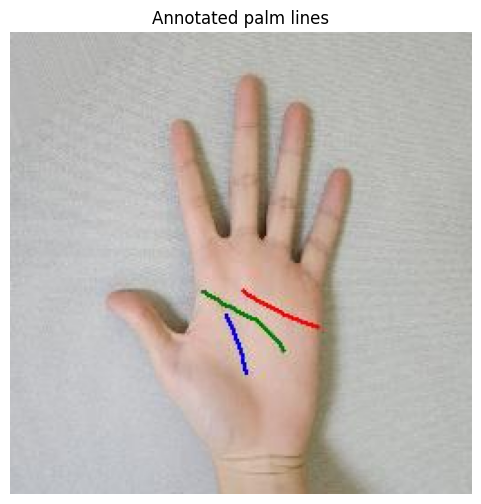

In [11]:
test_result = analyze_palm("input/hand1.jpg")

print("Success:", test_result["success"])
print("Error:", test_result.get("error"))

if test_result["success"]:
    for name, data in test_result["lines"].items():
        print(f"{name} → {data['relative_length']} ({data['length_px']} px)")

    from PIL import Image
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,6))
    plt.imshow(Image.open(test_result["result_image_path"]))
    plt.axis("off")
    plt.title("Annotated palm lines")
    plt.show()

## Palm LLM interpretation


In [12]:
LINE_MEANINGS = {
    "heart": "governs matters of the heart: romance, friendship, and commitment",
    "head": "governs intellectual curiosity and how the person approaches problems",
    "life": "reflects experiences, vitality and zest (NOT lifespan)",
}

def generate_palm_llm_reading(palm_data):
    """
    Takes the dict returned by analyze_palm() and asks the LLM for a natural-
    language palm reading (same pattern as generate_llm_reading() for tarot).
    """
    if not palm_data.get("success"):
        raise ValueError(f"Cannot generate a reading: {palm_data.get('error')}")

    line_context = []
    for name, info in palm_data["lines"].items():
        line_context.append(
            f"{name.capitalize()} Line: {info['relative_length']} "
            f"({info['length_px']} px) - {LINE_MEANINGS.get(name, '')}."
        )

    prompt = (
        "You are a warm, insightful palm reader. Based on the following detected "
        "palm-line measurements, write a short, natural, personalized reading "
        "(150-200 words) that weaves the three lines into one coherent narrative "
        "about the person's personality and life approach. Do not just repeat the "
        "measurements verbatim, and do not make medical or lifespan predictions.\n\n"
        + "\n".join(line_context)
    )

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content


### Test it on the palm we already analyzed

In [13]:
palm_reading = generate_palm_llm_reading(test_result)
print(palm_reading)


The story your palms tell is one of deep emotional connection and a passionate heart. With a heart line as long as yours, it's clear that relationships and personal connections are a vital source of nourishment for you. You have a tremendous capacity for love, empathy, and dedication, which draws people to you and fosters strong, lasting bonds.

While your intellectual curiosity may not drive you to constantly seek out new knowledge or overanalyze problems, you have a practical, instinctive approach to challenges. You trust your instincts and often rely on your emotional intelligence to guide your decisions.

Your life force is intense and focused, rather than widespread and meandering. This suggests that you pour your energy into the things that truly matter to you, and you're not afraid to take risks and dive deep into the experiences that bring you joy. Overall, your palms reveal a person who values connection, trusts their heart, and lives life with passion and purpose.


### Interpret every hand in the dataset


In [14]:
import shutil

def analyze_dataset_palms(dataset_dir=dataset_path, input_dir="input"):
    """Run the full palm pipeline + LLM interpretation on every image in dataset_dir."""
    os.makedirs(input_dir, exist_ok=True)
    results = []

    for fname in sorted(os.listdir(dataset_dir)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        local_path = os.path.join(input_dir, fname)
        shutil.copy(os.path.join(dataset_dir, fname), local_path)

        # give each image its own results subfolder so files don't overwrite
        # each other across the loop (that was causing every panel to show
        # the same, last-processed hand)
        image_results_dir = os.path.join("results", os.path.splitext(fname)[0])
        palm_data = analyze_palm(local_path, results_dir=image_results_dir)
        entry = {"filename": fname, "palm_data": palm_data, "reading": None}

        if palm_data["success"]:
            entry["reading"] = generate_palm_llm_reading(palm_data)
        else:
            print(f"⚠️ Skipped {fname}: {palm_data['error']}")

        results.append(entry)

    return results


dataset_palm_results = analyze_dataset_palms()

for entry in dataset_palm_results:
    print("=" * 60)
    print(entry["filename"])
    print("=" * 60)
    if entry["reading"]:
        print(entry["reading"])
    else:
        print("Failed:", entry["palm_data"]["error"])
    print()


my_palm_1.jpeg
The stories your palms tell. I see a deeply emotional and compassionate individual, with a heart that's always open to connection and love. Your long Heart Line suggests you're a romantic at heart, valuing meaningful relationships and friendships. You're likely a loyal and committed partner, always willing to go the extra mile for those you care about.

Interestingly, your shorter Head Line indicates a more intuitive and instinctual approach to problem-solving. You might not overthink things, instead trusting your gut feelings to guide you. This can sometimes lead to surprising breakthroughs and creative solutions.

Your shorter Life Line reveals a more relaxed and laid-back approach to life's experiences. You might not seek out excessive thrill or drama, instead finding joy in the everyday moments and simple pleasures. This blend of emotional depth, intuitive insight, and relaxed vitality makes you a lovely companion, and I sense you bring warmth and light to those arou

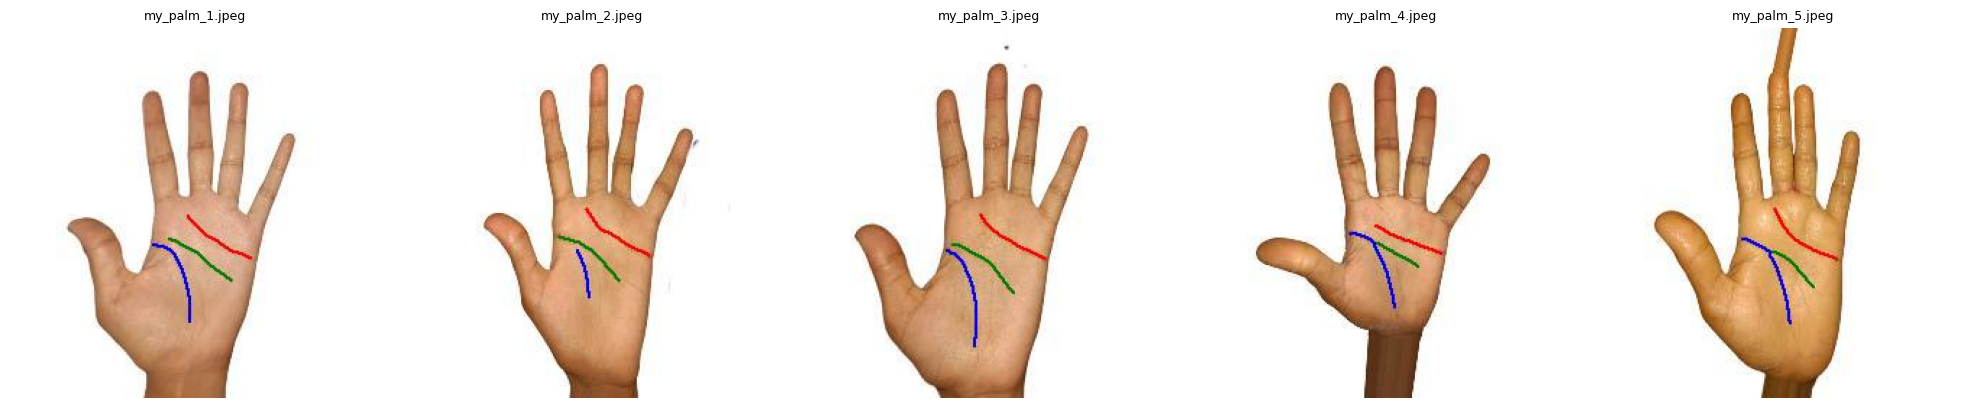

In [15]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt

successful = [e for e in dataset_palm_results if e["palm_data"]["success"]]

if successful:
    n = len(successful)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, entry in zip(axes, successful):
        ax.imshow(PILImage.open(entry["palm_data"]["result_image_path"]))
        ax.set_title(entry["filename"], fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No hands were successfully analyzed.")


## Tarot pipeline 

In [16]:
import pandas as pd
import random
import json as _json

# adjust these two paths to match your attached Kaggle dataset / local files
TAROT_DATA_PATH = "/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json"
TAROT_IMAGE_FOLDER = "/kaggle/input/datasets/lsind18/tarot-json/cards/"

with open(TAROT_DATA_PATH, "r") as f:
    tarot_data = _json.load(f)

tarot_df = pd.DataFrame(tarot_data["cards"])
print("Loaded", len(tarot_df), "cards")

SPREADS = {
    "1": {"name": "Single Card", "positions": ["Answer"]},
    "2": {"name": "Three Card (Past/Present/Future)", "positions": ["Past", "Present", "Future"]},
}


Loaded 78 cards


In [17]:
def draw_tarot_spread(df, n):
    drawn = df.sample(n).reset_index(drop=True)
    drawn["orientation"] = [random.choice(["upright", "reversed"]) for _ in range(n)]
    return drawn


def get_card_summary(card, orientation):
    meaning_list = (
        card["meanings"]["light"]
        if orientation == "upright"
        else card["meanings"]["shadow"]
    )

    return {
        "name": card["name"],
        "orientation": orientation,
        "keywords": ", ".join(card["keywords"][:3]),
        "meaning": random.choice(meaning_list),
        "fortune_telling": random.choice(card["fortune_telling"]),
    }


def generate_tarot_llm_reading(spread, positions):
    card_context = []

    for i, row in spread.iterrows():
        summary = get_card_summary(row, row["orientation"])

        position = positions[i] if i < len(positions) else f"Card {i+1}"

        card_context.append(
            f"{position}: {summary['name']} ({summary['orientation']}) - "
            f"Keywords: {summary['keywords']}. "
            f"Meaning: {summary['meaning']}"
        )

    prompt = (
        "You are a warm, insightful tarot reader. "
        "Based on the following spread, write a short personalized reading "
        "(150-200 words).\n\n"
        + "\n".join(card_context)
    )

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "user", "content": prompt}
        ],
    )

    return response.choices[0].message.content


def generate_combined_llm_reading(palm_reading_text, tarot_result):

    # Build card text (No _tarot_card_line needed)

    cards_text = "\n".join(
        f"{position}: {row['name']} ({row['orientation']})"
        for position, (_, row) in zip(
            tarot_result["positions"],
            tarot_result["cards"].iterrows()
        )
    )

    prompt = f"""
You are an experienced palmist and tarot reader.

Palm Reading:
{palm_reading_text}

Tarot Cards:
{cards_text}

Tarot Reading:
{tarot_result['reading']}

Using BOTH the palm reading and tarot reading, create ONE integrated reading.

Requirements:
- Explain how the tarot cards complement the palm reading.
- Do not repeat information.
- Write around 250-300 words.
- End with positive practical guidance.
"""

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
    )

    return response.choices[0].message.content


def run_tarot_reading(spread_key="2"):

    if spread_key not in SPREADS:
        spread_key = "2"

    chosen_spread = SPREADS[spread_key]

    n_cards = len(chosen_spread["positions"])

    spread = draw_tarot_spread(tarot_df, n_cards)

    reading = generate_tarot_llm_reading(
        spread,
        chosen_spread["positions"]
    )

    return {
        "spread_name": chosen_spread["name"],
        "positions": chosen_spread["positions"],
        "cards": spread,
        "reading": reading,
    }

### Choose a spread and draw 

Choose a tarot spread:
1. Single Card
2. Three Card (Past/Present/Future)


Enter choice number:  2
Type 'draw' to shuffle and pick your cards:  draw



Three Card (Past/Present/Future)
               name orientation
0       The Chariot     upright
1         The World     upright
2  Six of Pentacles     upright

The beautiful journey you've been on. In the past, you've demonstrated remarkable strength and leadership, rising to challenges and emerging victorious, as indicated by The Chariot. You've established yourself as a capable and worthy individual, and this confidence has served you well.

Currently, you're in a period of profound self-awareness and acceptance, symbolized by The World. You're embracing your entirety, flaws and all, and loving yourself with kindness and compassion. This wholeness is a powerful foundation for your future endeavors.

As you move forward, you're being called to share your gifts and resources with others, as seen in the Six of Pentacles. You're entering a phase of generosity and cooperation, where you'll find joy in supporting and uplifting those around you. Remember, this is not about seeking recogn

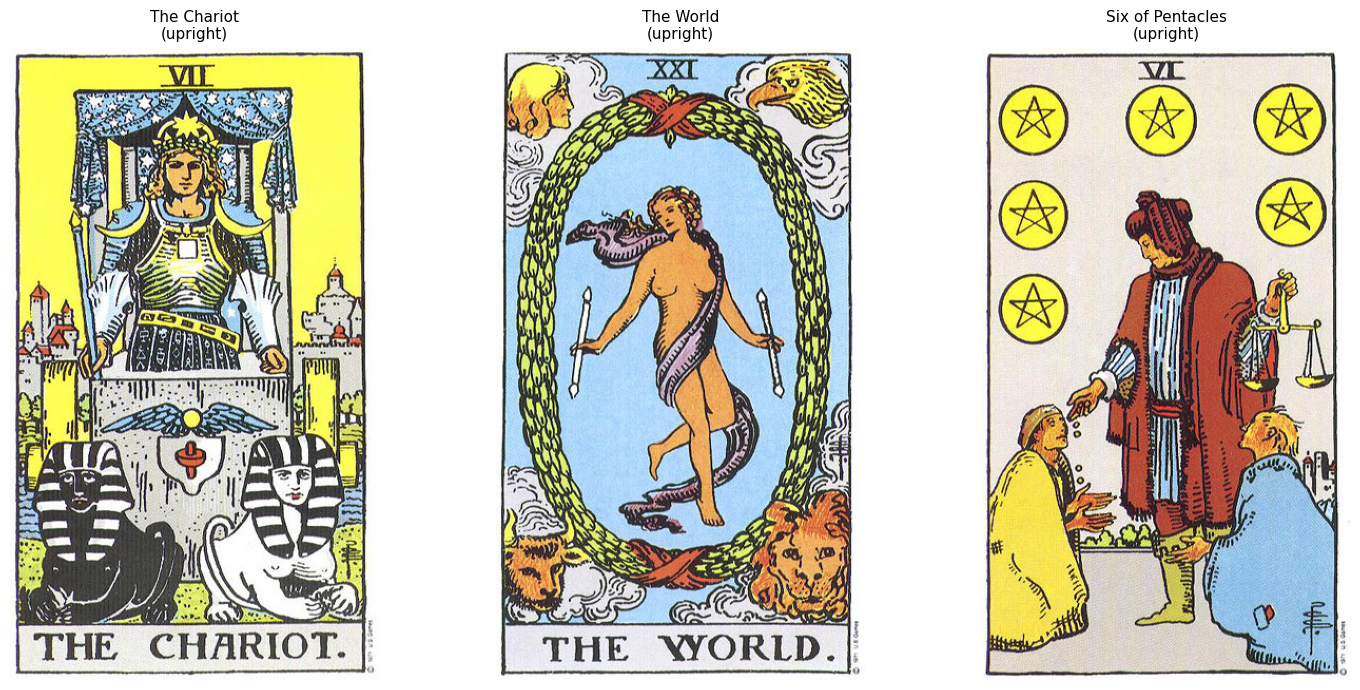

In [18]:
print("Choose a tarot spread:")
for key, val in SPREADS.items():
    print(f"{key}. {val['name']}")
spread_choice = input("Enter choice number: ").strip()
if spread_choice not in SPREADS:
    print("Invalid choice, defaulting to Three Card spread.")
    spread_choice = "2"

proceed = input("Type 'draw' to shuffle and pick your cards: ").strip().lower()

if proceed == "draw":
    tarot_result = run_tarot_reading(spread_key=spread_choice)
    combined_reading = generate_combined_llm_reading(
    palm_reading,
    tarot_result
    )
    print()
    print(tarot_result["spread_name"])
    print(tarot_result["cards"][["name", "orientation"]])
    print()
    print(tarot_result["reading"])
else:
    print("Draw cancelled — re-run this cell to try again.")
cards = tarot_result["cards"]

fig, axes = plt.subplots(1, len(cards), figsize=(5*len(cards),7))

if len(cards) == 1:
    axes = [axes]

for ax, (_, card) in zip(axes, cards.iterrows()):

    image_path = os.path.join(TAROT_IMAGE_FOLDER, card["img"])   # or card["image"]

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(
        f"{card['name']}\n({card['orientation']})",
        fontsize=11
    )
    ax.axis("off")

plt.tight_layout()
plt.show()
    


## PDF export — palm, tarot, and combined


In [19]:
from fpdf import FPDF
from fpdf.enums import XPos, YPos
from datetime import datetime

# Kaggle's file-download proxy serves files relative to /kaggle/working — but this
# notebook does `%cd palmistry/code` early on, so relative filenames like
# "palm_reading.pdf" were being saved *inside* that subfolder and the download link
# 404'd. Save PDFs directly into the working-dir root so the links always resolve.
PDF_OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.getcwd()

def _out_path(filename):
    return os.path.join(PDF_OUTPUT_DIR, filename)


def _safe_text(text):
    """Core PDF fonts only support latin-1; swap common Unicode punctuation
    the LLM tends to produce, then hard-fallback anything else."""
    replacements = {
        "\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"',
        "\u2013": "-", "\u2014": "-", "\u2026": "...",
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text.encode("latin-1", "replace").decode("latin-1")


def _pdf_base(title):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Helvetica", "B", 20)
    pdf.set_text_color(60, 20, 90)
    pdf.cell(0, 15, _safe_text(title), new_x=XPos.LMARGIN, new_y=YPos.NEXT, align="C")
    pdf.set_font("Helvetica", "", 10)
    pdf.set_text_color(120, 120, 120)
    pdf.cell(0, 8, datetime.now().strftime("%B %d, %Y"), new_x=XPos.LMARGIN, new_y=YPos.NEXT, align="C")
    pdf.ln(5)
    pdf.set_draw_color(200, 200, 200)
    pdf.line(15, pdf.get_y(), 195, pdf.get_y())
    pdf.ln(8)
    return pdf


def _add_section(pdf, heading, body_text, image_path=None):
    pdf.set_font("Helvetica", "B", 14)
    pdf.set_text_color(60, 20, 90)
    pdf.cell(0, 10, _safe_text(heading), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.set_font("Helvetica", "", 11)
    pdf.set_text_color(30, 30, 30)
    pdf.multi_cell(0, 7, _safe_text(body_text))
    pdf.ln(3)
    if image_path and os.path.exists(image_path):
        try:
            pdf.image(image_path, w=90)
            pdf.ln(5)
        except Exception:
            pass


def _tarot_card_line(tarot_result):
    return ", ".join(
        f"{pos}: {row['name']} ({row['orientation']})"
        for pos, (_, row) in zip(tarot_result["positions"], tarot_result["cards"].iterrows())
    )


def export_palm_pdf(palm_reading_text, palm_data, out_path="palm_reading.pdf"):
    out_path = _out_path(out_path)
    pdf = _pdf_base("Your Palm Reading")
    _add_section(pdf, "Palm Line Analysis", palm_reading_text, palm_data.get("result_image_path"))
    pdf.output(out_path)
    return out_path





def export_tarot_pdf(tarot_result, out_path="tarot_reading.pdf"):
    out_path = _out_path(out_path)

    pdf = _pdf_base("Your Tarot Reading - " + tarot_result["spread_name"])

    pdf.set_font("Helvetica", "I", 10)
    pdf.multi_cell(
        0,
        6,
        _safe_text("Cards drawn - " + _tarot_card_line(tarot_result))
    )

    pdf.ln(5)

    for position, (_, row) in zip(
            tarot_result["positions"],
            tarot_result["cards"].iterrows()):

        pdf.set_font("Helvetica","B",14)
        pdf.cell(0,8,f"{position}: {row['name']}",new_x=XPos.LMARGIN,new_y=YPos.NEXT)

        image_path = os.path.join(TAROT_IMAGE_FOLDER,row["img"])

        if os.path.exists(image_path):
            pdf.image(image_path,w=55)

        pdf.ln(3)

        pdf.set_font("Helvetica","",11)
        pdf.multi_cell(
            0,
            6,
            _safe_text(
                f"Orientation: {row['orientation']}\n"
                f"Keywords: {', '.join(row['keywords'])}\n"
            )
        )

        pdf.ln(5)

    _add_section(pdf,"Reading",tarot_result["reading"])

    pdf.output(out_path)

    return out_path


def export_combined_pdf(palm_reading_text,palm_data,tarot_result,combined_reading, out_path="combined_reading.pdf"
):
    out_path = _out_path(out_path)

    pdf = _pdf_base("Your Palm & Tarot Reading")

    # ---------------- Palm Reading ----------------
    _add_section(
    pdf,
    "Integrated Palm & Tarot Reading",
    combined_reading
    )
    # ---------------- Tarot Reading ----------------
    pdf.add_page()

    pdf.set_font("Helvetica", "B", 16)
    pdf.cell(0, 10, "Tarot Cards", new_x=XPos.LMARGIN, new_y=YPos.NEXT)

    for position, (_, row) in zip(
            tarot_result["positions"],
            tarot_result["cards"].iterrows()):

        pdf.set_font("Helvetica", "B", 13)
        pdf.cell(
            0,
            8,
            f"{position}: {row['name']} ({row['orientation']})",
            new_x=XPos.LMARGIN,
            new_y=YPos.NEXT
        )

        # Image path
        image_path = os.path.join(TAROT_IMAGE_FOLDER, row["img"])   # change "img" if your column has another name

        if os.path.exists(image_path):
            pdf.image(image_path, w=55)

        pdf.ln(5)

    pdf.ln(5)

    _add_section(
        pdf,
        "Tarot Interpretation",
        tarot_result["reading"]
    )

    pdf.output(out_path)

    return out_path


### Generate PDFs — palm, all-dataset palms, tarot, and combined


In [20]:
palm_pdf_path = export_palm_pdf(palm_reading, test_result)

tarot_pdf_path = export_tarot_pdf(tarot_result)
combined_pdf_path = export_combined_pdf(
    palm_reading,
    test_result,
    tarot_result,
    combined_reading
)
print("Palm PDF:", palm_pdf_path)

print("Tarot PDF:", tarot_pdf_path)
print("Combined PDF:", combined_pdf_path)

from IPython.display import FileLink, display as _display
for p in [palm_pdf_path, tarot_pdf_path, combined_pdf_path]:
    _display(FileLink(p))


Palm PDF: /kaggle/working/palm_reading.pdf
Tarot PDF: /kaggle/working/tarot_reading.pdf
Combined PDF: /kaggle/working/combined_reading.pdf


/kaggle/working/palm_reading.pdf

/kaggle/working/tarot_reading.pdf

/kaggle/working/combined_reading.pdf